# Lab 11: Simulating the Cavendish Experiment

## Introduction

The Cavendish Experiment, conducted by Henry Cavendish in 1798, was a groundbreaking attempt to measure the gravitational constant, $G$. This experiment provided the first accurate determination of $G$ and allowed scientists to calculate the mass and density of the Earth—a feat Cavendish called “weighing the Earth.”

In Newton’s equation:

$$F = G \frac{m_{1}m_{2}}{r^{2}}$$

$G$ is the constant that links the masses of two objects ($m_1, m_2$) and the distance ($r$) between them to the gravitational force ($F$).

Cavendish used a **torsion balance**, an apparatus with two small masses on a horizontal rod suspended by a thin wire. When two large stationary masses were brought near, their tiny gravitational pull twisted the rod. The wire resists this twist, providing a restoring torque:

$\tau_{\textrm{restore}}=-\kappa \theta$

where $\kappa$ is the torsional constant (stiffness) of the wire and $\theta$ is the angle of the twist.

This lab is a computational simulation of that experiment. Because we are building the simulation, we must "beg the question" by providing the physical constants, including $G$ and $\kappa$, to make the physics work.

### Our Lab's Structure
Our lab is split into two parts. This is a standard practice in computational physics: first, we verify our simulation engine, and *then* we add the complex physics.

1.  **Part 1: Verify the Torsion Model**: We simulate the *free oscillation* of the balance (no large masses). We will check if our simulated period matches the theoretical period. This proves our integrator (the loop) is working correctly.

2.  **Part 2: Verify the Gravitational Model**: We add the large masses and a damping force. We run the simulation to find the final resting (equilibrium) angle and compare it to the theoretical prediction.

##  The Physics of the Simulation

### Your Job

Our simulation runs in small time steps, `dt`. We must use an integrator to update the system's state. We will use the **Euler-Cromer method**:

Inside our loop, for each time step `dt`:

1.  Calculate the total net torque: $\tau_{\textrm{net}}​=\tau_{\textrm{grav}}+\tau_{\textrm{restore}}+\tau_{\textrm{damping}}$​
2.  Find the angular acceleration: $\alpha=\tau_{\textrm{net}}/I$
3.  Update the angular velocity: $\omega_{\textrm{new}}​=\omega_{\textrm{old}}+\alpha \cdot dt$
4.  Update the angle: $\theta_{\textrm{new}}​=\theta_{\textrm{old}}​+\omega_{\textrm{new}}\cdot dt$

This is a 1D (scalar) problem. All our variables ($\tau$, $\alpha$, $\omega$, $\theta$) are single numbers, as we are only concerned with rotation around the y-axis.

### The 3D Physics (A Helper Function)

The *actual* gravitational torque is complex. As the rod rotates, the 3D position vectors between all four masses change, which in turn changes the direction and magnitude of the force vectors. This requires 3D vector math ($\vec{r}$, $\vec{F}$) and cross products ($\vec{\tau} = \vec{r} \times \vec{F}$) to solve exactly.

To keep our lab focused on the integrator, we will use a **helper function** called `calculate_gravitational_torque()`. This function will perform all the 3D vector calculations internally and simply `return` the final, 1D scalar torque around the y-axis ($\tau_y$) that we need for our integrator.

## Part 1: Verify the Torsion Model & Measure the Period

**Objective:** In this part, we set $\tau_{\textrm{grav}}​=0$ and $\tau_{\textrm{damp}}​=0$. We will simulate the free oscillation and check if our simulated period ($T_{\textrm{sim}}$) matches the known theoretical period ($T_{\textrm{theory}}$).

The theoretical period of a torsion pendulum is:
$$T_{\textrm{theory}}​=2\pi \sqrt{\frac{I}{\kappa}}$$

The moment of inertia ($I$) for our rod with two small masses ($m$) at a distance ($L$) from the center is:
$$I=2mL^{2}$$

### Instructions:

1.  Run the code cell below to define all constants and calculate $T_{\textrm{theory}}$.
2.  Fill in the empty sections inside the `while` loop to implement the Euler-Cromer integrator.
    * For Part 1, the *only* torque is `tau_restore`.
3.  Run the simulation and observe the plot.
4.  The next code cell contains a program to *measure* the period from your simulation data. Fill in the empty sections there to complete the algorithm.
5.  Compare your $T_{\textrm{sim}}$ and $T_{\textrm{theory}}$​.

Moment of inertia: 0.0146
Theoretical period: 1200.4008674434747
\nRunning Part 1 simulation...
Simulation complete. Plotting results...


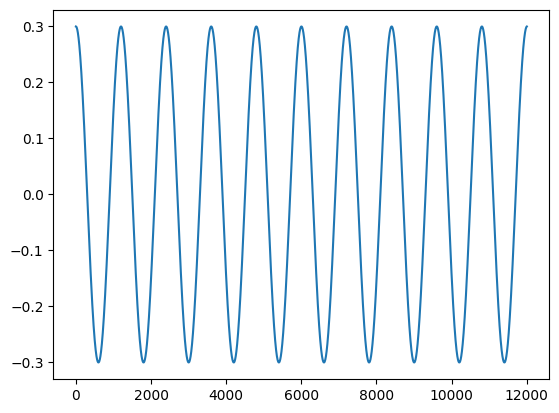

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Physical Constants ---
G = 6.674e-11                # Gravitational constant (N·m²/kg²)
large_mass = 158.0           # Mass of one large sphere (kg)
small_mass = 0.73            # Mass of one small sphere (kg)
L = 0.1                      # Half-length of the torsion rod (m)
d = 0.23                     # Separation distance used in approximation (m)
kappa = 4.0e-7               # Torsional constant (N·m/rad)
b = 2.0e-5                   # Damping constant (N·m·s/rad)

# --- Derived Constants ---
I = 2*small_mass*L*L # Moment of inertia
T_theory = 2*np.pi*np.sqrt(I/kappa)# equaiton above

print("Moment of inertia:", I)#print moment of inertia
print("Theoretical period:", T_theory)#print theoretical period

# --- Simulation Initial Conditions ---
theta = 0.3                  # Initial angle (rad)
omega = 0.0                  # Initial angular velocity (rad/s)
t = 0.0                      # Start time (s)
dt = 0.01                    # Time step (s)
t_max = 12000                # Max simulation time (s)needs to be big to get multiple periods

# --- Data Lists ---
t_data = []
theta_data = []

print("\\nRunning Part 1 simulation...") #helpful because it takes a little bit of time to run

while t < t_max:

    # 1. Calculate Net Torque
    tau = -kappa*theta

    # 2. Calculate Angular Acceleration
    alpha = tau/I

    # 3. Update Angular Velocity
    omega = omega + (alpha*dt)

    # 4. Update Angle
    theta = theta + (omega*dt)

    # Store data for plotting
    t_data.append(t)
    theta_data.append(theta)

    # Update time
    t = t + dt


print("Simulation complete. Plotting results...") #helpful because it takes a while

# --- Plotting --
#plot time vs angle inclue labels and title

plt.plot(t_data, theta_data)
plt.show()

### Task: Measuring the Period Algorithmically

"Eyeballing" the period from the plot is not precise. A robust computational method is to find the **"positive-going zero-crossing."** This is the moment the angle goes from *negative* to *positive*, an event that happens exactly once per cycle.

**Your Task:** Fill in the empty sections below to write a program that:
1.  Loops through the `theta_data`.
2.  Finds every time the angle crosses from negative to positive.
3.  Stores the *time* of these crossings.
4.  Calculates the period by finding the time difference between the first two crossings.

In [ ]:
# This list will store the *time* of each crossing
crossings = []
for i in range(1, len(theta_data)):
  if(theta_data[i] > 0 and theta_data[i-1] < 0):
    crossings.append(t_data[i])
    # Check if the *current* angle is positive AND the *previous* angle was negative (or zero)
        #Inside that check, if a crossing is found, append the *time* of that crossing (t_data[i])
if (len(crossings) >= 2):
  T_sim = crossings[1] - crossings[0]
  T_error = (T_sim - T_theory) / T_theory
  print("Theoretical period:", T_theory)
  print("Simulation period:", T_sim)
  print("Percent error:", T_error)
# Check if we found at least two crossings
  # If so, Calculate the period
  # Compare to theory
  #print out theory period, simulation period, and percent diff.

#print out if there was not a period found because the simulation did not have two crossings.

Theoretical period: 1200.4008674434747
Simulation period: 1200.4000000001063
Percent error: -7.226280752810528e-07


## Part 2: Verify the Gravitational Model & Find Equilibrium

**Objective:** Now we add the full physics. The gravitational force will create a torque. We will also add a small damping torque to help the system settle:

$$\tau_{\textrm{damp}}=-b\omega$$

The plot will show the rod oscillating and then settling at a new **equilibrium angle** ($\theta_{\textrm{eq}}$), where the gravitational torque exactly balances the restoring torque.

### The Theoretical (Approximate) Angle

At equilibrium, $\tau_{\textrm{net}}​=0$ and $\omega=0$. The torques balance:

$$\tau_{\textrm{grav}} \approx \tau_{\textrm{restore}} \implies \tau_{\textrm{grav}} \approx \kappa \theta_{\textrm{eq}}$$

A common *approximation* for the gravitational torque (which assumes the forces are perpendicular to the rod and ignores cross-terms) is:

$$\tau_{\textrm{grav}}\approx 2\cdot F_{\textrm{g}}\cdot L \approx 2 \left( G\frac{Mm}{d^{2}} \right) L$$

Setting the torques equal and solving for $\theta_{\textrm{theory}}$​ gives our target value:

$$\theta_{\textrm{theory}}=\frac{2GMmL}{\kappa d^{2}}$$

**Your Task**: Compare your $\theta_{\textrm{sim}}$​ (the final angle from the simulation) to this $\theta_{\textrm{theory}}$ calculation. They will be close, but not *exactly* the same. (Think about why!)

Theoretical (Approximate) Angle: 0.072758 radians
\nRunning Part 2 simulation (this may take a moment)...
Simulation complete. Plotting results...
Theorhetical Time Period 1200.4008674434747
Simulation Time Period 1200.4000000001063
Percent Error -7.226280752810528e-07
Theoretical angle: 0.07275795463137995
Simulation angle: 0.0460812241275823
Percent error: -0.3666503633719821
Gravitational constant (Simulated): 4.22697547485539e-11
Gravitational constant (Stored): 6.674e-11


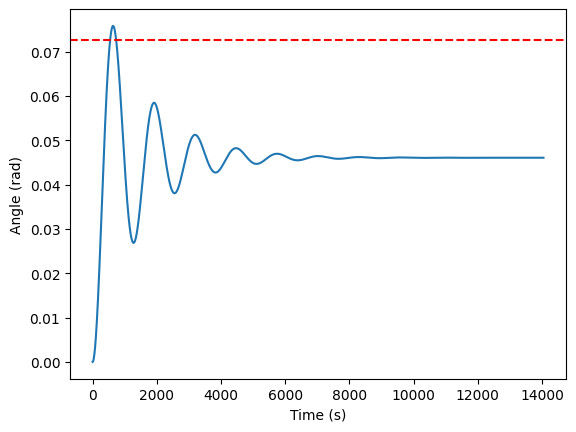

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- 3D Helper Function
# This function calculates the *exact* 3D vector torque from Graviation

def calculate_gravitational_torque(theta, L, d, M, m, G):
    """
    Calculates the exact gravitational torque on the torsion bar
    using full 3D vector math.
    """

    # Positions of small masses (rotating)
    small1_pos = np.array([ L * np.cos(theta), 0, -L * np.sin(theta)])
    small2_pos = np.array([-L * np.cos(theta), 0,  L * np.sin(theta)])

    # Positions of large masses (fixed)
    # This geometry matches the approximation at theta=0
    large1_pos = np.array([ L, 0, -d])
    large2_pos = np.array([-L, 0,  d])

    # --- Calculate 4 separation vectors (r = P_final - P_initial) ---
    r_s1_l1 = large1_pos - small1_pos
    r_s1_l2 = large2_pos - small1_pos
    r_s2_l1 = large1_pos - small2_pos
    r_s2_l2 = large2_pos - small2_pos

    # --- Calculate magnitudes ---
    mag_s1_l1 = np.linalg.norm(r_s1_l1)
    mag_s1_l2 = np.linalg.norm(r_s1_l2)
    mag_s2_l1 = np.linalg.norm(r_s2_l1)
    mag_s2_l2 = np.linalg.norm(r_s2_l2)

    # --- Calculate 4 Force vectors: F = G*M*m * (r_hat) / r^2 = G*M*m * r_vec / r^3 ---
    F_s1_l1 = G * M * m * r_s1_l1 / (mag_s1_l1**3)
    F_s1_l2 = G * M * m * r_s1_l2 / (mag_s1_l2**3)
    F_s2_l1 = G * M * m * r_s2_l1 / (mag_s2_l1**3)
    F_s2_l2 = G * M * m * r_s2_l2 / (mag_s2_l2**3)

    # --- Calculate total Force on each small mass ---
    F_on_s1 = F_s1_l1 + F_s1_l2
    F_on_s2 = F_s2_l1 + F_s2_l2

    # --- Calculate Torque (tau = r x F) ---
    # r is the lever arm (position vector from origin to small mass)
    tau1 = np.cross(small1_pos, F_on_s1)
    tau2 = np.cross(small2_pos, F_on_s2)

    # Total torque vector
    tau_net_vec = tau1 + tau2

    # Return *only* the y-component (the one that causes rotation)
    return tau_net_vec[1]

# --- Constants (defined again for a self-contained cell) ---
G = 6.674e-11
large_mass = 158.0
small_mass = 0.73
L = 0.1
d = 0.23
kappa = 4.0e-7
b = 2.0e-5
I = 2 * small_mass * L**2

# --- Calculate Theoretical (Approximate) Equilibrium ---
tau_grav_approx = 2 * G * large_mass * small_mass * L / (d**2)
theta_theory = tau_grav_approx / kappa

print(f"Theoretical (Approximate) Angle: {theta_theory:.6f} radians")

# --- Simulation Initial Conditions ---
theta = 0.0                  # Start from zero this time
omega = 0.0
t = 0.0
dt = 0.01
t_max = 20000                # Run longer to allow for damping

# --- Data Lists ---
t_data = []
theta_data = []

print("\\n Running Part 2 simulation (this may take a moment)...")

while t < t_max:

    # 1. Calculate Net Torque (All 3 components)
    tau_grav = calculate_gravitational_torque(theta, L, d, large_mass, small_mass, G)
    tau_damp = -b*omega
    tau_restore = -kappa*theta
    tau = tau_grav + tau_damp + tau_restore

    # 2. Calculate Angular Acceleration
    alpha = tau/I

    # 3. Update Angular Velocity (Euler-Cromer)
    omega = omega + (alpha*dt)

    # 4. Update Angle
    theta = theta + (omega*dt)

    # Store data
    t_data.append(t)
    theta_data.append(theta)

    # Update time
    t = t + dt

    # Break condition: Stop if it's settled
    if abs(omega) < 1e-10 and abs(alpha) < 1e-10 and t > 1000:
        # print(f"Equilibrium reached at t = {t:.1f} s")
        break

print("Simulation complete. Plotting results...")

# --- Final Analysis ---
theta_sim = theta_data[-1] # The last simulated angle is our equilibrium
#get percent difference between theory and simulation
theta_error = (theta_sim - theta_theory) / theta_theory

#print theory, simulation and percent difference
print("Theorhetical Time Period", T_theory)
print("Simulation Time Period", T_sim)
print("Percent Error", T_error)
print("Theoretical angle:", theta_theory)
print("Simulation angle:", theta_sim)
print("Percent error:", theta_error)
print("Gravitational constant (Simulated):", kappa*theta_sim*d*d/(2*large_mass*small_mass*L))
print("Gravitational constant (Stored):", G)

# --- Plotting ---
#plot time vs theta
plt.plot(t_data, theta_data)
plt.xlabel('Time (s)')
plt.ylabel('Angle (rad)')
plt.axhline(y=theta_theory, color='r', linestyle='--', label=f'Theoretical Eq. Angle = {theta_theory:.6f} rad')
#to get a line at the theory va
plt.show()

##  Analysis & Discussion

1.  **Part 1:** How close was your $T_{\textrm{sim}}$ (from your algorithm) to $T_{\textrm{theory}}$?

2.  **Part 2:** How close was your final $\theta_{\textrm{sim}}$ (from the simulation) to the $\theta_{\textrm{theory}}$ (from the approximation formula)?

3.  **Source of Error:** Our $\theta_{\textrm{theory}}$​ calculation used an *approximation* for the gravitational torque ($\tau \approx 2L \cdot F_g$). Our simulation, however, used the `calculate_gravitational_torque()` function, which calculated the *exact* vector forces (including the "cross-terms" from `small_mass_1` to `large_mass_2`, etc.) and how they change as $\theta$ changes. Could this explain the small percent difference between your simulated and theoretical answers?

4.  **The "Real" Experiment:** Cavendish, of course, did not know $G$. He worked backwards. He measured $T$ (to find $\kappa$), and he measured $\theta_{\textrm{eq}}$ (your $\theta_{\textrm{sim}}$). He then rearranged the final equation to solve for $G$:

    $$G=\frac{\kappa \theta_{\textrm{eq}}d^{2}}{2MmL}$$

    Using **your** simulated equilibrium angle ($\theta_{\textrm{sim}}$) as the "measured" value $\theta_{\textrm{eq}}$, what value do you calculate for $G$? How close is it to the real value we used in the code?